# Basic Blog Writing Agent

In [53]:
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

In [54]:
from __future__ import annotations
import operator
from typing import TypedDict, List, Annotated

In [55]:
from dotenv import load_dotenv

In [56]:
load_dotenv()

True

## Task Model

In [57]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description ='What to cover')

In [58]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [59]:
class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str], operator.add]
    final: str

In [60]:
llm = ChatOpenAI(model = 'gpt-4o')

In [61]:
def orchestrator(state: State) -> dict:
    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content = (
                    'Create a blog plan with 5-7 sections on the following topic.'
            )
            ),
            HumanMessage(
                content=f"Topic: {state['topic']}"
            )
        ]
    )
    return {"plan": plan}

In [62]:
def fanout(state:State):
    return [Send('worker', {'task':task, "topic": state['topic'], "plan": state['plan']}) for task in state['plan'].tasks]

In [63]:
def worker(payload: dict) -> dict:
    task = payload['task']
    topic = payload['topic']
    plan = payload['plan']

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(
                content='Write one clean Markdown Section'
            ),
            HumanMessage(
                content = (
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n"
                    f"Section: {task.title}\n"
                    f"Brief : {task.brief}\n\n"
                    "Return only the section content in Markdown"
                )
            )
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [64]:
from pathlib import Path
def reducer(state: State) -> dict:

    title = state['plan'].blog_title
    body = "\n\n".join(state['sections']).strip()

    final_md = f"# {title}\n\n{body}\n"

    filename= title.lower().replace(" ", "_") + '.md'
    output_path = Path(filename)
    output_path.write_text(final_md, encoding='utf-8')

    return {"final": final_md}

In [49]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node('worker', worker)
g.add_node('reducer', reducer)

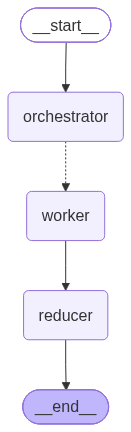

In [50]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges('orchestrator', fanout, ['worker'])
g.add_edge('worker', "reducer")
g.add_edge('reducer', END)

app = g.compile()
app

In [51]:
output = app.invoke({"topic": "Write a blog on Self Attention", "sections":[]})

In [52]:
output

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Understanding Self-Attention: A Key Concept in Modern AI', tasks=[Task(id=1, title='Introduction to Self-Attention', brief='Provide a basic introduction to the concept of self-attention, explaining its importance in artificial intelligence and machine learning. Mention how it revolutionized natural language processing.'), Task(id=2, title='The Mechanics Behind Self-Attention', brief='Explain how self-attention works. Discuss the process of calculating attention scores and using them to weigh the importance of different input tokens in a sequence. Utilize simple mathematical explanations and diagrams for clarity.'), Task(id=3, title='Self-Attention in Transformer Models', brief='Detail the role of self-attention within the architecture of transformer models. Explain how self-attention contributes to the parallel processing capabilities of transformers and their superior performance over previous sequential models.'), 